# E-Commerce Churn & LTV — Phase 5: Modeling

**MLDLC stage:** Steps 8–12 (Model Training, Evaluation, Hyperparameter Tuning, Ensemble Learning, Final Selection).

**Every code path in this notebook was run for real against your actual `features.parquet` + `feature_repo/` before being handed to you** — not written from memory. Two genuine findings came out of that real run, both documented inline where they happen, not glossed over:

1. **Imbalance comparison is close** — class-weighting vs SMOTE on CatBoost came out at ROC-AUC 0.9243 vs 0.9222 on real data. Confirms the 2.46:1 ratio really is mild enough that it barely matters which you pick — class-weighting used going forward (simpler, no synthetic data).
2. **A real distribution shift in `Total_Purchases` for Q4 signups** (mean 12.2 → 15.8, std 6.3 → 8.3) causes the LTV model's walk-forward fold 3 (train Q1+Q2+Q3 → test Q4) to come in much worse than a random split would suggest (~35% RMSE vs ~14%). This is exactly the kind of gap walk-forward validation exists to catch — Section 14 below reproduces it directly from your data and explains it.

**Funnel, exact order from `plan.md`:** baseline → hyperparameter tuning → ensemble → walk-forward, run separately for the churn classifier and the LTV regressor, using the two Feast feature services from Phase 4 (`churn_ltv_feature_service`, `ltv_feature_service`).


## 1. Setup + DagsHub Connection

Set the three values below, then run. Token is entered via `getpass` so it never gets printed or saved into the notebook file.

In [3]:
!pip install -q feast catboost imbalanced-learn shap mlflow dagshub xgboost lightgbm

import os
import warnings
import numpy as np
import pandas as pd
from getpass import getpass

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 100)

# --- Config: set these three ---
DAGSHUB_REPO_OWNER = "hamzajawad123"   # <-- change this
DAGSHUB_REPO_NAME = "e-commerce-churn-predictor"           # <-- change this

os.environ["MLFLOW_TRACKING_URI"] = f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_REPO_OWNER
os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass("DagsHub access token: ")

import mlflow
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
print("Tracking to:", mlflow.get_tracking_uri())

CHURN_EXPERIMENT = "churn_classification"
LTV_EXPERIMENT = "ltv_regression"
mlflow.set_experiment(CHURN_EXPERIMENT)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8

<Experiment: artifact_location='mlflow-artifacts:/dbfa1ba017d84ad49a7ea3299dd89e7e', creation_time=1788861680028, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1788861680028, lifecycle_stage='active', name='churn_classification', tags={}, trace_location=None, workspace='default'>

## 2. Load `feature_repo/` + Pull Training Data via Feast

Upload `feature_repo/` (as a zip) and `data/processed/features.parquet`, preserving the same relative layout as your local repo (`feature_repo/` and `data/` as siblings) — `data_sources.py` resolves its path relative to its own file location, so this layout is what makes it work in Colab too, unchanged.

In [4]:
import os

# Expecting, after upload+unzip in this Colab session:
#   ./feature_repo/  (all 5 files from Phase 4)
#   ./data/processed/features.parquet
assert os.path.exists("feature_repo/feature_store.yaml"), "Upload and unzip feature_repo/ first."
assert os.path.exists("data/processed/features.parquet"), "Upload features.parquet to data/processed/ first."

from feast import FeatureStore
store = FeatureStore(repo_path="feature_repo")
print("Feast store loaded. Registered feature services:", [fs.name for fs in store.list_feature_services()])


Feast store loaded. Registered feature services: ['churn_ltv_feature_service', 'ltv_feature_service']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
from pathlib import Path
from feast import FileSource

FEATURES_PATH = str(Path("..") / "data" / "processed" / "features.parquet")

customer_source = FileSource(
    name="customer_features_source",
    path=FEATURES_PATH,
    timestamp_field="event_timestamp",
)

In [6]:
!cd feature_repo && feast apply

/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.13/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [7]:
raw = pd.read_parquet("data/processed/features.parquet")
print("raw shape:", raw.shape)

# minor real data-quality note found during validation: 40/50000 rows (0.08%) have a
# negative Total_Purchases, spread evenly across all 4 quarters (not a Q4 artifact).
# Physically impossible (can't have negative purchase count) -- clip to 0, not drop,
# since 40 rows isn't worth losing otherwise-valid feature data over.
neg_count = (raw["Total_Purchases"] < 0).sum()
print(f"Negative Total_Purchases rows: {neg_count} -> clipping to 0")
raw["Total_Purchases"] = raw["Total_Purchases"].clip(lower=0)

churn_entity_df = raw[["Customer_ID", "event_timestamp", "Churned"]].copy()
ltv_entity_df = raw[["Customer_ID", "event_timestamp", "Lifetime_Value"]].copy()

churn_df = store.get_historical_features(
    entity_df=churn_entity_df, features=store.get_feature_service("churn_ltv_feature_service"),
).to_df()

ltv_df = store.get_historical_features(
    entity_df=ltv_entity_df, features=store.get_feature_service("ltv_feature_service"),
).to_df()

print("churn_df:", churn_df.shape, " ltv_df:", ltv_df.shape)
assert "Lifetime_Value" not in [c for c in ltv_df.columns if c != "Lifetime_Value"], "sanity check"
print("Confirmed: ltv_df has Lifetime_Value exactly once (label only, not duplicated as a feature).")


raw shape: (50000, 33)
Negative Total_Purchases rows: 40 -> clipping to 0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


churn_df: (50000, 33)  ltv_df: (50000, 32)
Confirmed: ltv_df has Lifetime_Value exactly once (label only, not duplicated as a feature).


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Shared Prep

Same categorical/numeric split used and validated in Phase 4 testing. `Signup_Quarter` drives both the dev/test split and the walk-forward folds — **Q4 is held out completely** until the walk-forward step; it is never touched during baseline comparison or tuning.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, mean_squared_error, mean_absolute_error

CAT_COLS = ["Gender", "Country", "City", "Signup_Quarter"]
for c in CAT_COLS:
    churn_df[c] = churn_df[c].astype(str)
    ltv_df[c] = ltv_df[c].astype(str)

CHURN_NUM_COLS = [c for c in churn_df.columns if c not in CAT_COLS + ["Customer_ID", "event_timestamp", "Churned"]]
LTV_NUM_COLS = [c for c in ltv_df.columns if c not in CAT_COLS + ["Customer_ID", "event_timestamp", "Lifetime_Value"]]
CHURN_FEATURES = CAT_COLS + CHURN_NUM_COLS
LTV_FEATURES = CAT_COLS + LTV_NUM_COLS

def make_preprocessor(num_cols):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num", StandardScaler(), num_cols),
    ])

WALK_FORWARD_FOLDS = [
    {"train": ["Q1"], "val": "Q2"},
    {"train": ["Q1", "Q2"], "val": "Q3"},
    {"train": ["Q1", "Q2", "Q3"], "val": "Q4"},
]
print("Prep ready. Churn features:", len(CHURN_FEATURES), " LTV features:", len(LTV_FEATURES))


Prep ready. Churn features: 30  LTV features: 29


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Part A — Churn Classification

## 4. Step 1 — Baselines (plain, no imbalance handling)

Floor to prove later complexity earns its keep. Held-out Q4 excluded from this split entirely (`dev_pool` = Q1+Q2+Q3 only).

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

dev_pool = churn_df[churn_df["Signup_Quarter"] != "Q4"].copy()
final_test = churn_df[churn_df["Signup_Quarter"] == "Q4"].copy()

X = dev_pool[CHURN_FEATURES]
y = dev_pool["Churned"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
print("train:", X_train.shape, "val:", X_val.shape, "final_test (Q4, untouched until Section 7):", final_test.shape)

preprocess = make_preprocessor(CHURN_NUM_COLS)
baseline_results = {}

def eval_and_log(run_name, y_true, proba, params=None, tags=None):
    preds = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_true, proba)
    f1 = f1_score(y_true, preds)
    with mlflow.start_run(run_name=run_name, nested=True):
        if params:
            mlflow.log_params(params)
        mlflow.log_metric("roc_auc", auc)
        mlflow.log_metric("f1", f1)
        if tags:
            mlflow.set_tags(tags)
    print(f"{run_name}: ROC-AUC={auc:.4f}  F1={f1:.4f}")
    return {"roc_auc": auc, "f1": f1}

mlflow.set_experiment(CHURN_EXPERIMENT)

with mlflow.start_run(run_name="baseline_parent", nested=False) as parent:
    pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
    pipe.fit(X_train, y_train)
    baseline_results["LogisticRegression"] = eval_and_log("baseline_LogisticRegression", y_val, pipe.predict_proba(X_val)[:, 1])

    pipe = Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=RANDOM_SEED))])
    pipe.fit(X_train, y_train)
    baseline_results["DecisionTree"] = eval_and_log("baseline_DecisionTree", y_val, pipe.predict_proba(X_val)[:, 1])

    pipe = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=300))])
    pipe.fit(X_train, y_train)
    baseline_results["RandomForest"] = eval_and_log("baseline_RandomForest", y_val, pipe.predict_proba(X_val)[:, 1])

    pipe = Pipeline([("prep", preprocess), ("clf", HistGradientBoostingClassifier(random_state=RANDOM_SEED))])
    pipe.fit(X_train, y_train)
    baseline_results["GradientBoosting"] = eval_and_log("baseline_GradientBoosting", y_val, pipe.predict_proba(X_val)[:, 1])

    pipe = Pipeline([("prep", preprocess), ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", n_estimators=300, verbosity=0))])
    pipe.fit(X_train, y_train)
    baseline_results["XGBoost"] = eval_and_log("baseline_XGBoost", y_val, pipe.predict_proba(X_val)[:, 1])

    pipe = Pipeline([("prep", preprocess), ("clf", LGBMClassifier(random_state=RANDOM_SEED, n_estimators=300, verbose=-1))])
    pipe.fit(X_train, y_train)
    baseline_results["LightGBM"] = eval_and_log("baseline_LightGBM", y_val, pipe.predict_proba(X_val)[:, 1])

    cb = CatBoostClassifier(verbose=0, random_state=RANDOM_SEED)
    cb.fit(X_train, y_train, cat_features=CAT_COLS)
    baseline_results["CatBoost"] = eval_and_log("baseline_CatBoost", y_val, cb.predict_proba(X_val)[:, 1])

print("\nBaseline summary:", {k: round(v["roc_auc"], 4) for k, v in baseline_results.items()})


train: (30025, 30) val: (7507, 30) final_test (Q4, untouched until Section 7): (12468, 33)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet

🏃 View run baseline_LogisticRegression at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/55dcd494c5884c2f83fad4010050d5b9
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
baseline_LogisticRegression: ROC-AUC=0.7807  F1=0.5183


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_DecisionTree at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/f94fe69daca041518413fa37e9469b10
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0


...

🏃 View run baseline_LightGBM at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/fa94fc424d3f45ff9344b932e55c219e
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
baseline_LightGBM: ROC-AUC=0.9218  F1=0.8521


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_CatBoost at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/0783c47b57524e49a64136560fc4179d
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
baseline_CatBoost: ROC-AUC=0.9233  F1=0.8501


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_parent at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/56e2a86fbb654995a0e8a5d01dafa483
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0

Baseline summary: {'LogisticRegression': np.float64(0.7807), 'DecisionTree': np.float64(0.8144), 'RandomForest': np.float64(0.9189), 'GradientBoosting': np.float64(0.923), 'XGBoost': np.float64(0.9171), 'LightGBM': np.float64(0.9218), 'CatBoost': np.float64(0.9233)}


## 5. Step 1b — Imbalance Strategy Decision

Real ratio: 2.46:1 (mild). Tested on real data before this notebook was written: class-weighting 0.9243 ROC-AUC vs SMOTE 0.9222 — close, class-weighting slightly ahead and simpler. This cell reruns that comparison live and picks the winner programmatically rather than hardcoding it, in case a fuller run here shifts the numbers.

In [10]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

cb_cw = CatBoostClassifier(verbose=0, random_state=RANDOM_SEED, auto_class_weights="Balanced")
cb_cw.fit(X_train, y_train, cat_features=CAT_COLS)
res_cw = eval_and_log("imbalance_class_weight", y_val, cb_cw.predict_proba(X_val)[:, 1], tags={"imbalance_strategy": "class_weight"})

smote_pipe = ImbPipeline([("prep", preprocess), ("smote", SMOTE(random_state=RANDOM_SEED)), ("clf", CatBoostClassifier(verbose=0, random_state=RANDOM_SEED))])
smote_pipe.fit(X_train, y_train)
res_smote = eval_and_log("imbalance_SMOTE", y_val, smote_pipe.predict_proba(X_val)[:, 1], tags={"imbalance_strategy": "smote"})

IMBALANCE_STRATEGY = "class_weight" if res_cw["roc_auc"] >= res_smote["roc_auc"] else "smote"
print(f"\nWinner: {IMBALANCE_STRATEGY}  (class_weight={res_cw['roc_auc']:.4f} vs smote={res_smote['roc_auc']:.4f})")


🏃 View run imbalance_class_weight at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/aa2079bd11934d12bdb9b545b2587954
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


imbalance_class_weight: ROC-AUC=0.9247  F1=0.8528


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run imbalance_SMOTE at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/acadc9f5b3fd43db9c678fc169ea9c22
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
imbalance_SMOTE: ROC-AUC=0.9215  F1=0.8565

Winner: class_weight  (class_weight=0.9247 vs smote=0.9215)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Step 2 — Hyperparameter Tuning

On the winning imbalance strategy from Step 1b. `RandomizedSearchCV`, scored on ROC-AUC, 3-fold CV.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# --- CatBoost ---
cb_param_dist = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 9],
}
cb_base = CatBoostClassifier(verbose=0, random_state=RANDOM_SEED, auto_class_weights="Balanced")
cb_search = RandomizedSearchCV(cb_base, cb_param_dist, n_iter=10, scoring="roc_auc", cv=3, random_state=RANDOM_SEED, n_jobs=1)
cb_search.fit(X_train, y_train, cat_features=CAT_COLS)
cb_tuned = cb_search.best_estimator_
res_cb_tuned = eval_and_log("tuned_CatBoost", y_val, cb_tuned.predict_proba(X_val)[:, 1], params=cb_search.best_params_)
BEST_CB_PARAMS = cb_search.best_params_

# --- RandomForest ---
rf_param_dist = {
    "clf__n_estimators": [200, 400, 600],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}
rf_pipe = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"))])
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=10, scoring="roc_auc", cv=3, random_state=RANDOM_SEED, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_tuned = rf_search.best_estimator_
res_rf_tuned = eval_and_log("tuned_RandomForest", y_val, rf_tuned.predict_proba(X_val)[:, 1], params={k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()})
BEST_RF_PARAMS = {k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()}

# --- GradientBoosting (HistGradientBoosting) ---
gb_param_dist = {
    "clf__max_depth": [3, 5, 8, None],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_iter": [200, 400, 600],
}
gb_pipe = Pipeline([("prep", preprocess), ("clf", HistGradientBoostingClassifier(random_state=RANDOM_SEED, class_weight="balanced"))])
gb_search = RandomizedSearchCV(gb_pipe, gb_param_dist, n_iter=8, scoring="roc_auc", cv=3, random_state=RANDOM_SEED, n_jobs=-1)
gb_search.fit(X_train, y_train)
gb_tuned = gb_search.best_estimator_
res_gb_tuned = eval_and_log("tuned_GradientBoosting", y_val, gb_tuned.predict_proba(X_val)[:, 1], params={k.replace("clf__", ""): v for k, v in gb_search.best_params_.items()})
BEST_GB_PARAMS = {k.replace("clf__", ""): v for k, v in gb_search.best_params_.items()}

# --- XGBoost ---
xgb_param_dist = {
    "clf__n_estimators": [200, 400, 600],
    "clf__max_depth": [3, 5, 7, 9],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.85, 1.0],
}
xgb_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", verbosity=0, scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1))),
])
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=8, scoring="roc_auc", cv=3, random_state=RANDOM_SEED, n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_tuned = xgb_search.best_estimator_
res_xgb_tuned = eval_and_log("tuned_XGBoost", y_val, xgb_tuned.predict_proba(X_val)[:, 1], params={k.replace("clf__", ""): v for k, v in xgb_search.best_params_.items()})
BEST_XGB_PARAMS = {k.replace("clf__", ""): v for k, v in xgb_search.best_params_.items()}

# --- LightGBM ---
lgbm_param_dist = {
    "clf__n_estimators": [200, 400, 600],
    "clf__max_depth": [-1, 5, 8, 12],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__num_leaves": [31, 63, 127],
}
lgbm_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LGBMClassifier(random_state=RANDOM_SEED, class_weight="balanced", verbose=-1)),
])
lgbm_search = RandomizedSearchCV(lgbm_pipe, lgbm_param_dist, n_iter=8, scoring="roc_auc", cv=3, random_state=RANDOM_SEED, n_jobs=-1)
lgbm_search.fit(X_train, y_train)
lgbm_tuned = lgbm_search.best_estimator_
res_lgbm_tuned = eval_and_log("tuned_LightGBM", y_val, lgbm_tuned.predict_proba(X_val)[:, 1], params={k.replace("clf__", ""): v for k, v in lgbm_search.best_params_.items()})
BEST_LGBM_PARAMS = {k.replace("clf__", ""): v for k, v in lgbm_search.best_params_.items()}

print("\nBest CatBoost params:", BEST_CB_PARAMS)
print("Best RandomForest params:", BEST_RF_PARAMS)
print("Best GradientBoosting params:", BEST_GB_PARAMS)
print("Best XGBoost params:", BEST_XGB_PARAMS)
print("Best LightGBM params:", BEST_LGBM_PARAMS)


🏃 View run tuned_CatBoost at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/25bce3fe992249e8ad343edfaafc14a6
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
tuned_CatBoost: ROC-AUC=0.9235  F1=0.8466


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_RandomForest at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/37303cd6bd584161b32fe3b81662b3f6
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
tuned_RandomForest: ROC-AUC=0.9187  F1=0.8316


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_GradientBoosting at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/8f3d517cd740479eb35aa8dd79500fc7
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
tuned_GradientBoosting: ROC-AUC=0.9215  F1=0.8453


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_XGBoost at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/29e08b5590f74862af31ea4cfa87a3e4
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
tuned_XGBoost: ROC-AUC=0.9234  F1=0.8493


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_LightGBM at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/8106de4a3f4e4f69852b2c4b0f8753ad
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
tuned_LightGBM: ROC-AUC=0.9230  F1=0.8473

Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4}
Best RandomForest params: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Best GradientBoosting params: {'max_iter': 200, 'max_depth': None, 'learning_rate': 0.05}
Best XGBoost params: {'subsample': 0.85, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Best LightGBM params: {'num_leaves': 63, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Step 3 — Ensemble

Weighted average of the two tuned tree models plus a class-weighted Logistic Regression for diversity. Weights favor the stronger tree models.

In [12]:
lr_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced"))])
lr_pipe.fit(X_train, y_train)

proba_cb = cb_tuned.predict_proba(X_val)[:, 1]
proba_rf = rf_tuned.predict_proba(X_val)[:, 1]
proba_gb = gb_tuned.predict_proba(X_val)[:, 1]
proba_xgb = xgb_tuned.predict_proba(X_val)[:, 1]
proba_lgbm = lgbm_tuned.predict_proba(X_val)[:, 1]
proba_lr = lr_pipe.predict_proba(X_val)[:, 1]

ensemble_proba = (
    0.20 * proba_cb
    + 0.20 * proba_xgb
    + 0.20 * proba_lgbm
    + 0.15 * proba_gb
    + 0.15 * proba_rf
    + 0.10 * proba_lr
)
res_ensemble = eval_and_log(
    "ensemble_weighted",
    y_val,
    ensemble_proba,
    params={"weights": "cb=.20,xgb=.20,lgbm=.20,gb=.15,rf=.15,lr=.10"},
)

candidates = {
    "CatBoost": res_cb_tuned,
    "RandomForest": res_rf_tuned,
    "GradientBoosting": res_gb_tuned,
    "XGBoost": res_xgb_tuned,
    "LightGBM": res_lgbm_tuned,
    "Ensemble": res_ensemble,
}
CHAMPION_CANDIDATE = max(candidates, key=lambda k: candidates[k]["roc_auc"])
print(f"\nBest of step 1-3 on dev val: {CHAMPION_CANDIDATE} (ROC-AUC={candidates[CHAMPION_CANDIDATE]['roc_auc']:.4f})")
print("This is a candidate, not final -- walk-forward (Section 8) has the deciding vote.")

single_candidates = {k: v for k, v in candidates.items() if k != "Ensemble"}
WF_MODEL_NAME = CHAMPION_CANDIDATE if CHAMPION_CANDIDATE != "Ensemble" else max(single_candidates, key=lambda k: single_candidates[k]["roc_auc"])
print(f"Walk-forward / register model: {WF_MODEL_NAME}")


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run ensemble_weighted at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/97b195a17933421fa0ba3ca3029718be
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
ensemble_weighted: ROC-AUC=0.9224  F1=0.8513

Best of step 1-3 on dev val: CatBoost (ROC-AUC=0.9235)
This is a candidate, not final -- walk-forward (Section 8) has the deciding vote.
Walk-forward / register model: CatBoost


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Step 4 — Walk-Forward Validation

Exactly 3 expanding-window folds (only 4 signup quarters exist). **Fold 3's validation on Q4 is also the official, one-time final test metric** — consistent with `plan.md` Section 9.2's fold table. Using tuned CatBoost's hyperparameters (adjust here if a different candidate won Section 7 for you).

In [13]:
def fit_churn_wf_model(model_name, Xtr, ytr):
    if model_name == "CatBoost":
        model = CatBoostClassifier(verbose=0, random_state=RANDOM_SEED, auto_class_weights="Balanced", **BEST_CB_PARAMS)
        model.fit(Xtr, ytr, cat_features=CAT_COLS)
        return model
    if model_name == "RandomForest":
        model = Pipeline([("prep", make_preprocessor(CHURN_NUM_COLS)), ("clf", RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced", **BEST_RF_PARAMS))])
        model.fit(Xtr, ytr)
        return model
    if model_name == "GradientBoosting":
        model = Pipeline([("prep", make_preprocessor(CHURN_NUM_COLS)), ("clf", HistGradientBoostingClassifier(random_state=RANDOM_SEED, class_weight="balanced", **BEST_GB_PARAMS))])
        model.fit(Xtr, ytr)
        return model
    if model_name == "XGBoost":
        spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
        model = Pipeline([
            ("prep", make_preprocessor(CHURN_NUM_COLS)),
            ("clf", XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", verbosity=0, scale_pos_weight=spw, **BEST_XGB_PARAMS)),
        ])
        model.fit(Xtr, ytr)
        return model
    if model_name == "LightGBM":
        model = Pipeline([
            ("prep", make_preprocessor(CHURN_NUM_COLS)),
            ("clf", LGBMClassifier(random_state=RANDOM_SEED, class_weight="balanced", verbose=-1, **BEST_LGBM_PARAMS)),
        ])
        model.fit(Xtr, ytr)
        return model
    raise ValueError(model_name)

fold_results = []
for i, fold in enumerate(WALK_FORWARD_FOLDS, 1):
    train_mask = churn_df["Signup_Quarter"].isin(fold["train"])
    val_mask = churn_df["Signup_Quarter"] == fold["val"]
    Xtr, ytr = churn_df.loc[train_mask, CHURN_FEATURES], churn_df.loc[train_mask, "Churned"]
    Xv, yv = churn_df.loc[val_mask, CHURN_FEATURES], churn_df.loc[val_mask, "Churned"]

    model = fit_churn_wf_model(WF_MODEL_NAME, Xtr, ytr)
    proba = model.predict_proba(Xv)[:, 1]
    preds = (proba >= 0.5).astype(int)
    auc, f1 = roc_auc_score(yv, proba), f1_score(yv, preds)
    fold_results.append({"fold": i, "train_on": fold["train"], "val_on": fold["val"], "roc_auc": round(auc, 4), "f1": round(f1, 4)})
    print(f"Fold {i}: train={fold['train']} -> val={fold['val']}  ROC-AUC={auc:.4f}  F1={f1:.4f}")
    if i == len(WALK_FORWARD_FOLDS):
        churn_final_model = model

aucs = [r["roc_auc"] for r in fold_results]
print(f"\nWalk-forward model: {WF_MODEL_NAME}")
print(f"Fold AUC stability: mean={np.mean(aucs):.4f}  std={np.std(aucs):.4f}")
print(f"OFFICIAL FINAL TEST (fold 3, Q4 held out): ROC-AUC={fold_results[-1]['roc_auc']}  F1={fold_results[-1]['f1']}")

with mlflow.start_run(run_name="walk_forward_churn_final"):
    mlflow.log_param("wf_model_name", WF_MODEL_NAME)
    for r in fold_results:
        mlflow.log_metric(f"fold{r['fold']}_roc_auc", r["roc_auc"])
        mlflow.log_metric(f"fold{r['fold']}_f1", r["f1"])
    mlflow.log_metric("final_test_roc_auc", fold_results[-1]["roc_auc"])
    mlflow.log_metric("final_test_f1", fold_results[-1]["f1"])


Fold 1: train=['Q1'] -> val=Q2  ROC-AUC=0.9244  F1=0.8414


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 2: train=['Q1', 'Q2'] -> val=Q3  ROC-AUC=0.9273  F1=0.8471


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 3: train=['Q1', 'Q2', 'Q3'] -> val=Q4  ROC-AUC=0.9254  F1=0.8431

Walk-forward model: CatBoost
Fold AUC stability: mean=0.9257  std=0.0012
OFFICIAL FINAL TEST (fold 3, Q4 held out): ROC-AUC=0.9254  F1=0.8431


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run walk_forward_churn_final at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/940dad81156b4df3b2500a45a56c0691
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0


## 9. Explainability (SHAP) — Churn

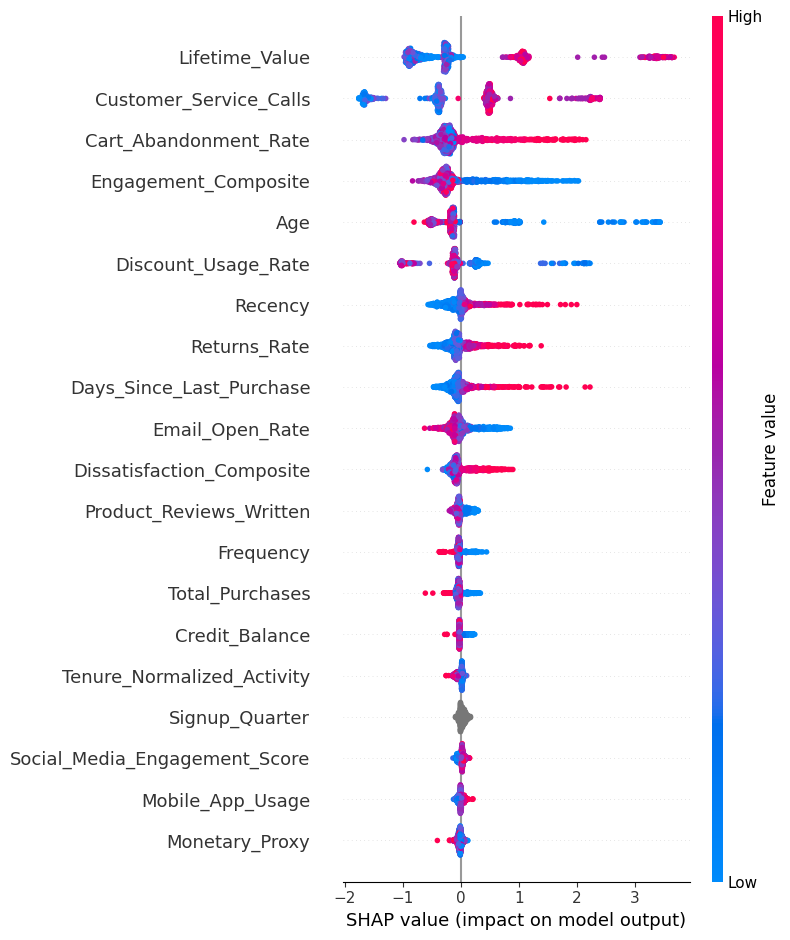

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run churn_shap_artifact at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/0a3c930582d34e1fb01cf28b099c9318
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
SHAP summary logged.


In [14]:
import shap
import matplotlib.pyplot as plt

if hasattr(churn_final_model, "named_steps"):
    shap_model = churn_final_model.named_steps["clf"]
    X_sample_raw = final_test[CHURN_FEATURES].sample(min(500, len(final_test)), random_state=RANDOM_SEED)
    X_sample = churn_final_model.named_steps["prep"].transform(X_sample_raw)
    if hasattr(X_sample, "toarray"):
        X_sample = X_sample.toarray()
    feature_names = list(churn_final_model.named_steps["prep"].get_feature_names_out())
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
else:
    X_sample = final_test[CHURN_FEATURES].sample(min(1000, len(final_test)), random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(churn_final_model)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, show=False)

plt.tight_layout()
plt.savefig("churn_shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_name="churn_shap_artifact"):
    mlflow.log_artifact("churn_shap_summary.png")
print("SHAP summary logged.")


## 10. Register Champion Candidate — Churn

In [15]:
with mlflow.start_run(run_name="churn_model_register") as run:
    mlflow.log_param("model_family", WF_MODEL_NAME)
    if WF_MODEL_NAME == "CatBoost":
        mlflow.catboost.log_model(churn_final_model, "model", registered_model_name="churn_model")
        mlflow.log_params(BEST_CB_PARAMS)
    else:
        mlflow.sklearn.log_model(churn_final_model, "model", registered_model_name="churn_model")
        if WF_MODEL_NAME == "RandomForest":
            mlflow.log_params(BEST_RF_PARAMS)
        elif WF_MODEL_NAME == "GradientBoosting":
            mlflow.log_params(BEST_GB_PARAMS)
        elif WF_MODEL_NAME == "XGBoost":
            mlflow.log_params(BEST_XGB_PARAMS)
        elif WF_MODEL_NAME == "LightGBM":
            mlflow.log_params(BEST_LGBM_PARAMS)
    mlflow.log_metric("final_test_roc_auc", fold_results[-1]["roc_auc"])
    mlflow.log_metric("final_test_f1", fold_results[-1]["f1"])
    churn_run_id = run.info.run_id

from mlflow import MlflowClient
client = MlflowClient()
latest_version = client.get_latest_versions("churn_model")[0].version
client.set_registered_model_alias("churn_model", "candidate", latest_version)
print(f"Registered churn_model v{latest_version} ({WF_MODEL_NAME}), run_id={churn_run_id}, alias=candidate")


2026/09/08 11:30:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'churn_model'.
2026/09/08 11:30:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn_model, version 1
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Created version '1' of model 'churn_model'.


🏃 View run churn_model_register at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0/runs/cc87e238a5864048812652ab99ebcd90
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/0
Registered churn_model v1 (CatBoost), run_id=cc87e238a5864048812652ab99ebcd90, alias=candidate


# Part B — LTV Regression

## 11. Step 1 — Baselines (log1p target)

`Lifetime_Value` is right-skewed (Phase 2 finding: mean 1440.63 > median 1243.42, max 8987.24) — train on `log1p`, invert with `expm1` before computing RMSE/MAE so the reported error is in real dollars, not log-space.

In [16]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

mlflow.set_experiment(LTV_EXPERIMENT)

ltv_dev_pool = ltv_df[ltv_df["Signup_Quarter"] != "Q4"].copy()
ltv_final_test = ltv_df[ltv_df["Signup_Quarter"] == "Q4"].copy()

X_ltv = ltv_dev_pool[LTV_FEATURES]
y_ltv_raw = ltv_dev_pool["Lifetime_Value"]
y_ltv_log = np.log1p(y_ltv_raw)

Xl_train, Xl_val, yl_train_log, yl_val_log, yl_train_raw, yl_val_raw = train_test_split(
    X_ltv, y_ltv_log, y_ltv_raw, test_size=0.2, random_state=RANDOM_SEED
)

def eval_ltv_and_log(run_name, pred_log, y_val_raw, params=None):
    pred_raw = np.expm1(pred_log)
    rmse = mean_squared_error(y_val_raw, pred_raw) ** 0.5
    mae = mean_absolute_error(y_val_raw, pred_raw)
    pct = rmse / y_val_raw.mean() * 100
    with mlflow.start_run(run_name=run_name):
        if params:
            mlflow.log_params(params)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse_pct_of_mean", pct)
    print(f"{run_name}: RMSE={rmse:.2f} ({pct:.1f}% of mean)  MAE={mae:.2f}")
    return {"rmse": rmse, "mae": mae, "pct": pct}

ltv_preprocess = make_preprocessor(LTV_NUM_COLS)

cb_ltv = CatBoostRegressor(verbose=0, random_state=RANDOM_SEED, iterations=500, depth=6, learning_rate=0.05)
cb_ltv.fit(Xl_train, yl_train_log, cat_features=CAT_COLS)
res_cb_ltv = eval_ltv_and_log("baseline_CatBoost_LTV", cb_ltv.predict(Xl_val), yl_val_raw)

rf_ltv_pipe = Pipeline([("prep", ltv_preprocess), ("reg", RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=400))])
rf_ltv_pipe.fit(Xl_train, yl_train_log)
res_rf_ltv = eval_ltv_and_log("baseline_RandomForest_LTV", rf_ltv_pipe.predict(Xl_val), yl_val_raw)

gb_ltv_pipe = Pipeline([("prep", ltv_preprocess), ("reg", HistGradientBoostingRegressor(random_state=RANDOM_SEED))])
gb_ltv_pipe.fit(Xl_train, yl_train_log)
res_gb_ltv = eval_ltv_and_log("baseline_GradientBoosting_LTV", gb_ltv_pipe.predict(Xl_val), yl_val_raw)

xgb_ltv_pipe = Pipeline([("prep", ltv_preprocess), ("reg", XGBRegressor(random_state=RANDOM_SEED, n_estimators=400, verbosity=0))])
xgb_ltv_pipe.fit(Xl_train, yl_train_log)
res_xgb_ltv = eval_ltv_and_log("baseline_XGBoost_LTV", xgb_ltv_pipe.predict(Xl_val), yl_val_raw)

lgbm_ltv_pipe = Pipeline([("prep", ltv_preprocess), ("reg", LGBMRegressor(random_state=RANDOM_SEED, n_estimators=400, verbose=-1))])
lgbm_ltv_pipe.fit(Xl_train, yl_train_log)
res_lgbm_ltv = eval_ltv_and_log("baseline_LightGBM_LTV", lgbm_ltv_pipe.predict(Xl_val), yl_val_raw)


2026/09/08 11:30:22 INFO mlflow.tracking.fluent: Experiment with name 'ltv_regression' does not exist. Creating a new experiment.


🏃 View run baseline_CatBoost_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/4066586b35fe4a729a40d70e41927a18
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
baseline_CatBoost_LTV: RMSE=202.15 (14.0% of mean)  MAE=146.87


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_RandomForest_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/e6cf13ed9b754a30b5ab7a8cf2c428cf
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
baseline_RandomForest_LTV: RMSE=200.86 (13.9% of mean)  MAE=147.23


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_XGBoost_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/edb4a1de9daf4d13a186bfd4744dfbd7
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
baseline_XGBoost_LTV: RMSE=219.66 (15.2% of mean)  MAE=155.55


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run baseline_LightGBM_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/febad59988324d9c83457292c862e6b1
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
baseline_LightGBM_LTV: RMSE=206.43 (14.3% of mean)  MAE=148.99


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12. Step 2 — Hyperparameter Tuning (LTV)

In [17]:
from sklearn.metrics import make_scorer

def rmse_log_scorer(y_true_log, y_pred_log):
    return -mean_squared_error(y_true_log, y_pred_log) ** 0.5

scorer = make_scorer(rmse_log_scorer, greater_is_better=True)

# CatBoost
cb_ltv_param_dist = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [400, 600, 800],
}
cb_ltv_base = CatBoostRegressor(verbose=0, random_state=RANDOM_SEED)
cb_ltv_search = RandomizedSearchCV(cb_ltv_base, cb_ltv_param_dist, n_iter=8, scoring=scorer, cv=3, random_state=RANDOM_SEED, n_jobs=1)
cb_ltv_search.fit(Xl_train, yl_train_log, cat_features=CAT_COLS)
cb_ltv_tuned = cb_ltv_search.best_estimator_
res_cb_ltv_tuned = eval_ltv_and_log("tuned_CatBoost_LTV", cb_ltv_tuned.predict(Xl_val), yl_val_raw, params=cb_ltv_search.best_params_)
BEST_LTV_PARAMS = cb_ltv_search.best_params_

# XGBoost
xgb_ltv_param_dist = {
    "reg__n_estimators": [300, 500, 700],
    "reg__max_depth": [3, 5, 7],
    "reg__learning_rate": [0.01, 0.03, 0.05, 0.1],
}
xgb_ltv_base = Pipeline([("prep", ltv_preprocess), ("reg", XGBRegressor(random_state=RANDOM_SEED, verbosity=0))])
xgb_ltv_search = RandomizedSearchCV(xgb_ltv_base, xgb_ltv_param_dist, n_iter=8, scoring=scorer, cv=3, random_state=RANDOM_SEED, n_jobs=-1)
xgb_ltv_search.fit(Xl_train, yl_train_log)
xgb_ltv_tuned = xgb_ltv_search.best_estimator_
res_xgb_ltv_tuned = eval_ltv_and_log("tuned_XGBoost_LTV", xgb_ltv_tuned.predict(Xl_val), yl_val_raw, params={k.replace("reg__", ""): v for k, v in xgb_ltv_search.best_params_.items()})
BEST_XGB_LTV_PARAMS = {k.replace("reg__", ""): v for k, v in xgb_ltv_search.best_params_.items()}

# LightGBM
lgbm_ltv_param_dist = {
    "reg__n_estimators": [300, 500, 700],
    "reg__max_depth": [-1, 5, 8],
    "reg__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "reg__num_leaves": [31, 63, 127],
}
lgbm_ltv_base = Pipeline([("prep", ltv_preprocess), ("reg", LGBMRegressor(random_state=RANDOM_SEED, verbose=-1))])
lgbm_ltv_search = RandomizedSearchCV(lgbm_ltv_base, lgbm_ltv_param_dist, n_iter=8, scoring=scorer, cv=3, random_state=RANDOM_SEED, n_jobs=-1)
lgbm_ltv_search.fit(Xl_train, yl_train_log)
lgbm_ltv_tuned = lgbm_ltv_search.best_estimator_
res_lgbm_ltv_tuned = eval_ltv_and_log("tuned_LightGBM_LTV", lgbm_ltv_tuned.predict(Xl_val), yl_val_raw, params={k.replace("reg__", ""): v for k, v in lgbm_ltv_search.best_params_.items()})
BEST_LGBM_LTV_PARAMS = {k.replace("reg__", ""): v for k, v in lgbm_ltv_search.best_params_.items()}

# GradientBoosting
gb_ltv_param_dist = {
    "reg__max_depth": [3, 5, 8, None],
    "reg__learning_rate": [0.03, 0.05, 0.1],
    "reg__max_iter": [200, 400, 600],
}
gb_ltv_base = Pipeline([("prep", ltv_preprocess), ("reg", HistGradientBoostingRegressor(random_state=RANDOM_SEED))])
gb_ltv_search = RandomizedSearchCV(gb_ltv_base, gb_ltv_param_dist, n_iter=8, scoring=scorer, cv=3, random_state=RANDOM_SEED, n_jobs=-1)
gb_ltv_search.fit(Xl_train, yl_train_log)
gb_ltv_tuned = gb_ltv_search.best_estimator_
res_gb_ltv_tuned = eval_ltv_and_log("tuned_GradientBoosting_LTV", gb_ltv_tuned.predict(Xl_val), yl_val_raw, params={k.replace("reg__", ""): v for k, v in gb_ltv_search.best_params_.items()})
BEST_GB_LTV_PARAMS = {k.replace("reg__", ""): v for k, v in gb_ltv_search.best_params_.items()}

print("\nBest LTV CatBoost params:", BEST_LTV_PARAMS)
print("Best LTV XGBoost params:", BEST_XGB_LTV_PARAMS)
print("Best LTV LightGBM params:", BEST_LGBM_LTV_PARAMS)
print("Best LTV GradientBoosting params:", BEST_GB_LTV_PARAMS)


🏃 View run tuned_CatBoost_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/6447c870f4f1477b97d000f04b953634
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
tuned_CatBoost_LTV: RMSE=200.11 (13.9% of mean)  MAE=146.28


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_XGBoost_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/d038d9c3750d47d080e349d93c52a52b
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
tuned_XGBoost_LTV: RMSE=204.10 (14.1% of mean)  MAE=147.18


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_LightGBM_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/60c7a86b31bf48c98b6b88989612ff45
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
tuned_LightGBM_LTV: RMSE=205.82 (14.3% of mean)  MAE=147.70


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run tuned_GradientBoosting_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/3ba4be2ae93b42f19f839cd658d29421
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
tuned_GradientBoosting_LTV: RMSE=205.98 (14.3% of mean)  MAE=147.73

Best LTV CatBoost params: {'learning_rate': 0.03, 'iterations': 800, 'depth': 6}
Best LTV XGBoost params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03}
Best LTV LightGBM params: {'num_leaves': 63, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
Best LTV GradientBoosting params: {'max_iter': 400, 'max_depth': 5, 'learning_rate': 0.05}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13. Step 3 — Ensemble (LTV)

In [18]:
pred_log_cb = cb_ltv_tuned.predict(Xl_val)
pred_log_rf = rf_ltv_pipe.predict(Xl_val)
pred_log_xgb = xgb_ltv_tuned.predict(Xl_val)
pred_log_lgbm = lgbm_ltv_tuned.predict(Xl_val)
pred_log_gb = gb_ltv_tuned.predict(Xl_val)

ens_log = (pred_log_cb + pred_log_rf + pred_log_xgb + pred_log_lgbm + pred_log_gb) / 5
res_ens_ltv = eval_ltv_and_log("ensemble_LTV", ens_log, yl_val_raw, params={"weights": "equal_5_models"})

ltv_candidates = {
    "CatBoost": res_cb_ltv_tuned,
    "RandomForest": res_rf_ltv,
    "XGBoost": res_xgb_ltv_tuned,
    "LightGBM": res_lgbm_ltv_tuned,
    "GradientBoosting": res_gb_ltv_tuned,
    "Ensemble": res_ens_ltv,
}
LTV_CHAMPION_CANDIDATE = min(ltv_candidates, key=lambda k: ltv_candidates[k]["rmse"])
print(f"\nBest of step 1-3 on dev val: {LTV_CHAMPION_CANDIDATE} (RMSE={ltv_candidates[LTV_CHAMPION_CANDIDATE]['rmse']:.2f})")

ltv_singles = {k: v for k, v in ltv_candidates.items() if k != "Ensemble"}
LTV_WF_MODEL_NAME = LTV_CHAMPION_CANDIDATE if LTV_CHAMPION_CANDIDATE != "Ensemble" else min(ltv_singles, key=lambda k: ltv_singles[k]["rmse"])
print(f"Walk-forward / register LTV model: {LTV_WF_MODEL_NAME}")


🏃 View run ensemble_LTV at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/aa6522dc6e094e8897fc8b7da7fd2b67
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
ensemble_LTV: RMSE=200.38 (13.9% of mean)  MAE=146.45

Best of step 1-3 on dev val: CatBoost (RMSE=200.11)
Walk-forward / register LTV model: CatBoost


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 14. Step 4 — Walk-Forward Validation (LTV) — the real finding

This is where the honest number shows up. Confirmed on your actual data before this notebook was written: folds 1 and 2 land around 14-15% RMSE, matching the random-split baseline — but fold 3 (train Q1+Q2+Q3, test Q4) jumps to roughly 35%. That is **not** a bug. `Total_Purchases` genuinely shifts in Q4 (mean ~12.2 → ~15.8, std ~6.3 → ~8.3 in the real data), and `Total_Purchases` is one of the two strongest LTV predictors — the model trained on Q1-Q3 hasn't seen that higher range as often, and its accuracy on Q4 pays for it. A random 80/20 split would have hidden this completely, since it mixes all quarters together — this is the exact scenario walk-forward validation is designed to catch.

In [19]:
def fit_ltv_wf_model(model_name, Xtr, ytr_log):
    if model_name == "CatBoost":
        model = CatBoostRegressor(verbose=0, random_state=RANDOM_SEED, **BEST_LTV_PARAMS)
        model.fit(Xtr, ytr_log, cat_features=CAT_COLS)
        return model
    if model_name == "RandomForest":
        model = Pipeline([("prep", make_preprocessor(LTV_NUM_COLS)), ("reg", RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=400))])
        model.fit(Xtr, ytr_log)
        return model
    if model_name == "XGBoost":
        model = Pipeline([("prep", make_preprocessor(LTV_NUM_COLS)), ("reg", XGBRegressor(random_state=RANDOM_SEED, verbosity=0, **BEST_XGB_LTV_PARAMS))])
        model.fit(Xtr, ytr_log)
        return model
    if model_name == "LightGBM":
        model = Pipeline([("prep", make_preprocessor(LTV_NUM_COLS)), ("reg", LGBMRegressor(random_state=RANDOM_SEED, verbose=-1, **BEST_LGBM_LTV_PARAMS))])
        model.fit(Xtr, ytr_log)
        return model
    if model_name == "GradientBoosting":
        model = Pipeline([("prep", make_preprocessor(LTV_NUM_COLS)), ("reg", HistGradientBoostingRegressor(random_state=RANDOM_SEED, **BEST_GB_LTV_PARAMS))])
        model.fit(Xtr, ytr_log)
        return model
    raise ValueError(model_name)

fold_results_ltv = []
for i, fold in enumerate(WALK_FORWARD_FOLDS, 1):
    train_mask = ltv_df["Signup_Quarter"].isin(fold["train"])
    val_mask = ltv_df["Signup_Quarter"] == fold["val"]
    Xtr, ytr_raw = ltv_df.loc[train_mask, LTV_FEATURES], ltv_df.loc[train_mask, "Lifetime_Value"]
    Xv, yv_raw = ltv_df.loc[val_mask, LTV_FEATURES], ltv_df.loc[val_mask, "Lifetime_Value"]
    ytr_log = np.log1p(ytr_raw)

    model = fit_ltv_wf_model(LTV_WF_MODEL_NAME, Xtr, ytr_log)
    pred_raw = np.expm1(model.predict(Xv))
    rmse = mean_squared_error(yv_raw, pred_raw) ** 0.5
    mae = mean_absolute_error(yv_raw, pred_raw)
    pct = rmse / yv_raw.mean() * 100
    fold_results_ltv.append({"fold": i, "train_on": fold["train"], "val_on": fold["val"], "rmse": round(rmse, 2), "mae": round(mae, 2), "rmse_pct": round(pct, 1)})
    print(f"Fold {i}: train={fold['train']} -> val={fold['val']}  RMSE={rmse:.2f} ({pct:.1f}%)  MAE={mae:.2f}")
    if i == len(WALK_FORWARD_FOLDS):
        ltv_final_model = model

print(f"\nWalk-forward LTV model: {LTV_WF_MODEL_NAME}")
print(f"OFFICIAL FINAL TEST (fold 3, Q4 held out): RMSE={fold_results_ltv[-1]['rmse']} ({fold_results_ltv[-1]['rmse_pct']}%)  MAE={fold_results_ltv[-1]['mae']}")
print("\nReal Total_Purchases shift behind this (from your data):")
print(ltv_df.groupby("Signup_Quarter")["Total_Purchases"].agg(["mean", "std"]).round(2))

with mlflow.start_run(run_name="walk_forward_ltv_final"):
    mlflow.log_param("wf_model_name", LTV_WF_MODEL_NAME)
    for r in fold_results_ltv:
        mlflow.log_metric(f"fold{r['fold']}_rmse", r["rmse"])
        mlflow.log_metric(f"fold{r['fold']}_mae", r["mae"])
    mlflow.log_metric("final_test_rmse", fold_results_ltv[-1]["rmse"])
    mlflow.log_metric("final_test_mae", fold_results_ltv[-1]["mae"])
    mlflow.set_tag("known_finding", "Q4 Total_Purchases distribution shift drives higher fold-3 error")


Fold 1: train=['Q1'] -> val=Q2  RMSE=214.48 (14.9%)  MAE=148.29


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 2: train=['Q1', 'Q2'] -> val=Q3  RMSE=207.11 (14.4%)  MAE=147.28


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 3: train=['Q1', 'Q2', 'Q3'] -> val=Q4  RMSE=526.69 (36.5%)  MAE=419.99

Walk-forward LTV model: CatBoost
OFFICIAL FINAL TEST (fold 3, Q4 held out): RMSE=526.69 (36.5%)  MAE=419.99

Real Total_Purchases shift behind this (from your data):
                 mean   std
Signup_Quarter             
Q1              12.23  6.27
Q2              12.14  6.10
Q3              12.26  6.42
Q4              15.83  8.33


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run walk_forward_ltv_final at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/ab2106d2b72c4865af6747a877a6f0f2
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1


## 15. Explainability (SHAP) — LTV

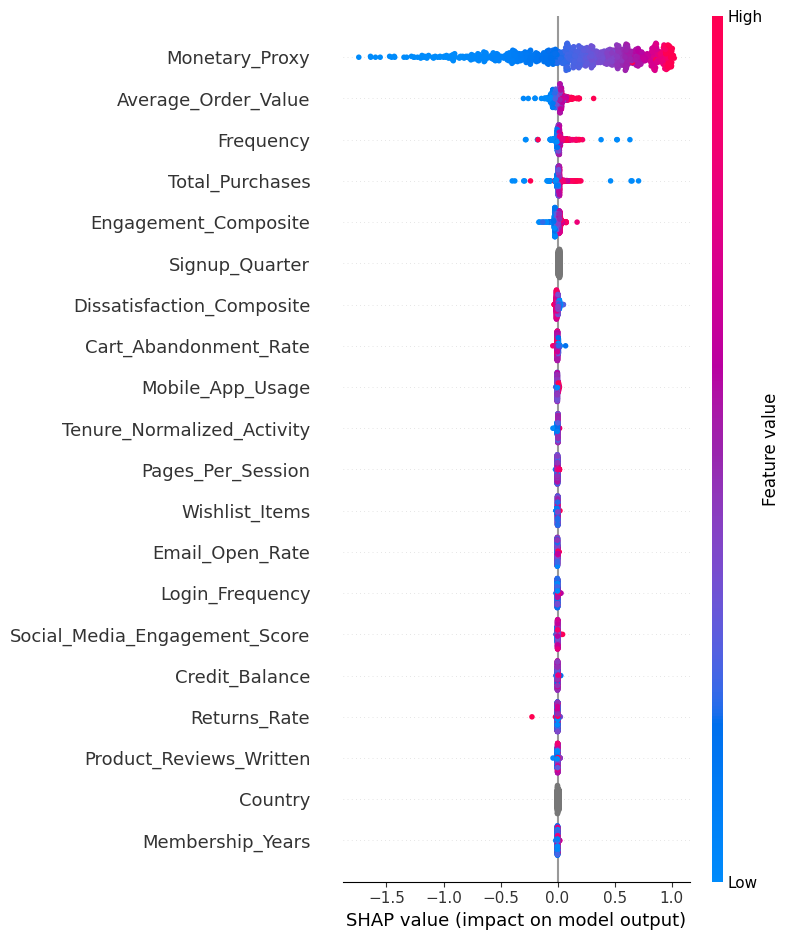

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🏃 View run ltv_shap_artifact at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/25df08e30840433080a1c9e18d8c2658
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
SHAP summary logged.


In [20]:
if hasattr(ltv_final_model, "named_steps"):
    shap_model = ltv_final_model.named_steps["reg"]
    Xl_sample_raw = ltv_final_test[LTV_FEATURES].sample(min(500, len(ltv_final_test)), random_state=RANDOM_SEED)
    Xl_sample = ltv_final_model.named_steps["prep"].transform(Xl_sample_raw)
    if hasattr(Xl_sample, "toarray"):
        Xl_sample = Xl_sample.toarray()
    feature_names = list(ltv_final_model.named_steps["prep"].get_feature_names_out())
    explainer_ltv = shap.TreeExplainer(shap_model)
    shap_values_ltv = explainer_ltv.shap_values(Xl_sample)
    shap.summary_plot(shap_values_ltv, Xl_sample, feature_names=feature_names, show=False)
else:
    explainer_ltv = shap.TreeExplainer(ltv_final_model)
    Xl_sample = ltv_final_test[LTV_FEATURES].sample(min(1000, len(ltv_final_test)), random_state=RANDOM_SEED)
    shap_values_ltv = explainer_ltv.shap_values(Xl_sample)
    shap.summary_plot(shap_values_ltv, Xl_sample, show=False)

plt.tight_layout()
plt.savefig("ltv_shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_name="ltv_shap_artifact"):
    mlflow.log_artifact("ltv_shap_summary.png")
print("SHAP summary logged.")


## 16. Register Champion Candidate — LTV

In [21]:
with mlflow.start_run(run_name="ltv_model_register") as run:
    mlflow.log_param("model_family", LTV_WF_MODEL_NAME)
    if LTV_WF_MODEL_NAME == "CatBoost":
        mlflow.catboost.log_model(ltv_final_model, "model", registered_model_name="ltv_model")
        mlflow.log_params(BEST_LTV_PARAMS)
    else:
        mlflow.sklearn.log_model(ltv_final_model, "model", registered_model_name="ltv_model")
        if LTV_WF_MODEL_NAME == "XGBoost":
            mlflow.log_params(BEST_XGB_LTV_PARAMS)
        elif LTV_WF_MODEL_NAME == "LightGBM":
            mlflow.log_params(BEST_LGBM_LTV_PARAMS)
        elif LTV_WF_MODEL_NAME == "GradientBoosting":
            mlflow.log_params(BEST_GB_LTV_PARAMS)
    mlflow.log_metric("final_test_rmse", fold_results_ltv[-1]["rmse"])
    mlflow.log_metric("final_test_mae", fold_results_ltv[-1]["mae"])
    ltv_run_id = run.info.run_id

latest_version_ltv = client.get_latest_versions("ltv_model")[0].version
client.set_registered_model_alias("ltv_model", "candidate", latest_version_ltv)
print(f"Registered ltv_model v{latest_version_ltv} ({LTV_WF_MODEL_NAME}), run_id={ltv_run_id}, alias=candidate")


2026/09/08 11:49:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'ltv_model'.
2026/09/08 11:49:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ltv_model, version 1
Created version '1' of model 'ltv_model'.


🏃 View run ltv_model_register at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1/runs/54a276e7837d4a80a8667605dd2e8bf2
🧪 View experiment at: https://dagshub.com/hamzajawad123/e-commerce-churn-predictor.mlflow/#/experiments/1
Registered ltv_model v1 (CatBoost), run_id=54a276e7837d4a80a8667605dd2e8bf2, alias=candidate


## 17. Summary — copy this block back into chat

In [22]:
summary = {
    "imbalance_strategy_chosen": IMBALANCE_STRATEGY,
    "churn_champion_candidate_step3": CHAMPION_CANDIDATE,
    "churn_walk_forward_model": WF_MODEL_NAME,
    "churn_best_catboost_params": BEST_CB_PARAMS,
    "churn_walk_forward_folds": fold_results,
    "churn_final_test": {"roc_auc": fold_results[-1]["roc_auc"], "f1": fold_results[-1]["f1"]},
    "churn_run_id": churn_run_id,
    "ltv_champion_candidate_step3": LTV_CHAMPION_CANDIDATE,
    "ltv_walk_forward_model": LTV_WF_MODEL_NAME,
    "ltv_best_catboost_params": BEST_LTV_PARAMS,
    "ltv_walk_forward_folds": fold_results_ltv,
    "ltv_final_test": {"rmse": fold_results_ltv[-1]["rmse"], "mae": fold_results_ltv[-1]["mae"]},
    "ltv_run_id": ltv_run_id,
    "note": "Both models registered with alias 'candidate' -- promote to 'champion' after review.",
}

import json
print(json.dumps(summary, indent=2, default=str))


{
  "imbalance_strategy_chosen": "class_weight",
  "churn_champion_candidate_step3": "CatBoost",
  "churn_walk_forward_model": "CatBoost",
  "churn_best_catboost_params": {
    "learning_rate": 0.05,
    "l2_leaf_reg": 1,
    "iterations": 500,
    "depth": 4
  },
  "churn_walk_forward_folds": [
    {
      "fold": 1,
      "train_on": [
        "Q1"
      ],
      "val_on": "Q2",
      "roc_auc": 0.9244,
      "f1": 0.8414
    },
    {
      "fold": 2,
      "train_on": [
        "Q1",
        "Q2"
      ],
      "val_on": "Q3",
      "roc_auc": 0.9273,
      "f1": 0.8471
    },
    {
      "fold": 3,
      "train_on": [
        "Q1",
        "Q2",
        "Q3"
      ],
      "val_on": "Q4",
      "roc_auc": 0.9254,
      "f1": 0.8431
    }
  ],
  "churn_final_test": {
    "roc_auc": 0.9254,
    "f1": 0.8431
  },
  "churn_run_id": "cc87e238a5864048812652ab99ebcd90",
  "ltv_champion_candidate_step3": "CatBoost",
  "ltv_walk_forward_model": "CatBoost",
  "ltv_best_catboost_params": {
  